# `GenomeView` test-drive

[`GenomeView`](https://genomeview.readthedocs.io/en/latest/index.html) is a
pure-Python genome viewer that renders directly to SVG. It's designed for
*static, publication-quality* output and integrates with Jupyter — placing a
`Document` on the last line of a cell auto-renders the SVG inline.

We'll mirror the structure of `notebook.ipynb` here so you can A/B the output
against our hand-rolled matplotlib version. Everything is built from Python
data (no BAM / BED / FASTA files needed); GenomeView also accepts those if
you have them.

In [1]:
import numpy as np

import genomeview
from genomeview import (
    Axis,
    Document,
    GenomeView,
    GraphTrack,
    Interval,
    IntervalTrack,
)

rng = np.random.default_rng(0)
length = 500
positions = np.arange(length)

signal = 20 + 15 * np.exp(-((positions - 150) ** 2) / (2 * 30**2))
signal += 25 * np.exp(-((positions - 350) ** 2) / (2 * 50**2))
coverage = np.maximum(0, signal + rng.normal(0, 2, size=length)).round().astype(int)

## 1. Coverage track + gene track

The basic anatomy of a GenomeView document:

- **`Document(width)`** holds one or more `GenomeView` rows.
- **`GenomeView(chrom, start, end, strand)`** is a single horizontal panel.
- **Tracks** (`Axis`, `GraphTrack`, `IntervalTrack`, BAM/BED/BigWig tracks)
  stack vertically inside a view.

Returning the `Document` at the end of the cell triggers GenomeView's
`_repr_svg_` and renders inline.

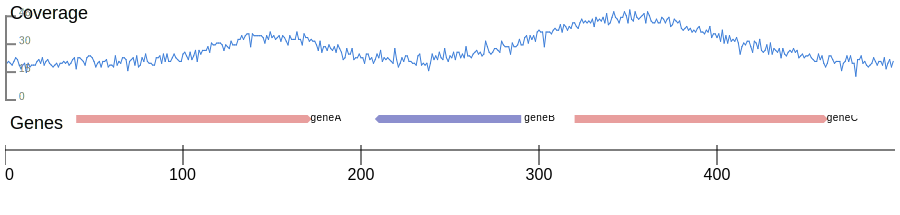

In [2]:
doc = Document(900)
view = GenomeView("chr1", 0, length, "+")

cov = GraphTrack("Coverage")
cov.add_series(positions.tolist(), coverage.tolist(), color="#3b7dd8")
view.add_track(cov)

genes = [
    Interval("g1", "chr1", 40, 170, "+", label="geneA"),
    Interval("g2", "chr1", 210, 290, "-", label="geneB"),
    Interval("g3", "chr1", 320, 460, "+", label="geneC"),
]
view.add_track(IntervalTrack(genes, "Genes"))

view.add_track(Axis())
doc.add_view(view)
genomeview.save(doc, "plots/genomeview_01_basic.svg")
doc

## 2. Forward + reverse coverage on the same track

`GraphTrack.add_series` accepts multiple datasets. Plotted on a shared
y-axis with different colors — handy for stranded coverage.

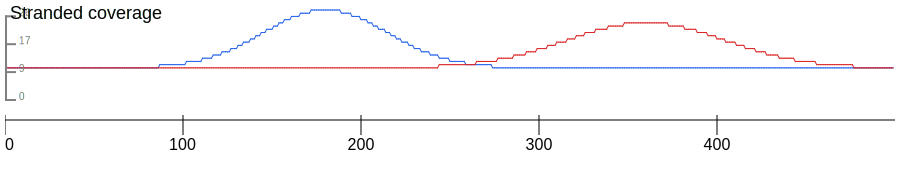

In [3]:
forward = (10 + 18 * np.exp(-((positions - 180) ** 2) / (2 * 35**2))).round().astype(int)
reverse = (10 + 14 * np.exp(-((positions - 360) ** 2) / (2 * 45**2))).round().astype(int)

doc = Document(900)
view = GenomeView("chr1", 0, length, "+")

stranded = GraphTrack("Stranded coverage")
stranded.add_series(positions.tolist(), forward.tolist(), color="#2563eb", label="+ strand")
stranded.add_series(positions.tolist(), reverse.tolist(), color="#dc2626", label="- strand")
view.add_track(stranded)

view.add_track(Axis())
doc.add_view(view)
genomeview.save(doc, "plots/genomeview_02_stranded.svg")
doc

## 3. Multiple genomic regions in one figure

A `Document` can hold several `GenomeView` rows — handy for comparing
non-contiguous regions (e.g. two loci) in a single SVG.

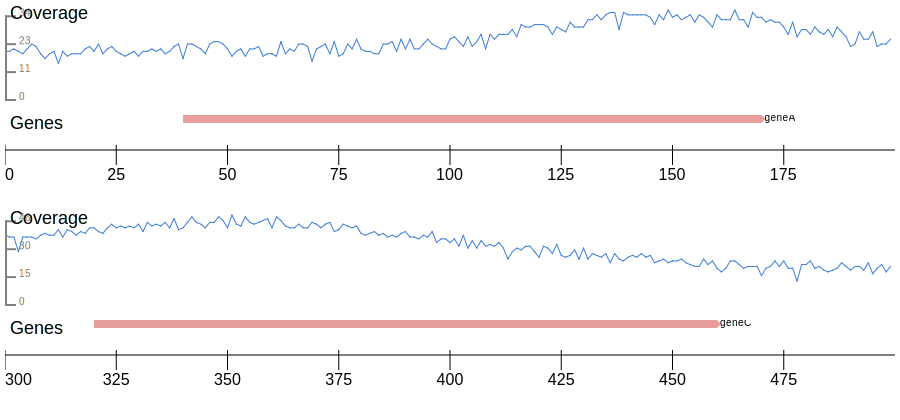

In [4]:
doc = Document(900)

for region_start, region_end, title in [(0, 200, "5' region"), (300, 500, "3' region")]:
    view = GenomeView("chr1", region_start, region_end, "+", name=title)
    mask = (positions >= region_start) & (positions < region_end)
    cov = GraphTrack("Coverage")
    cov.add_series(positions[mask].tolist(), coverage[mask].tolist(), color="#3b7dd8")
    view.add_track(cov)
    region_genes = [g for g in genes if g.end > region_start and g.start < region_end]
    if region_genes:
        view.add_track(IntervalTrack(region_genes, "Genes"))
    view.add_track(Axis())
    doc.add_view(view)

genomeview.save(doc, "plots/genomeview_03_multi_region.svg")
doc

## 4. Vector output

Each cell above already wrote its SVG to `plots/genomeview_*.svg` via
`genomeview.save(doc, path)`. SVG is the native format; pass a `.png` or
`.pdf` path and GenomeView will rasterize via `librsvg`, `inkscape`, or
`webkitToPDF` if any of those is on `$PATH`.

In [5]:
import pathlib

for p in sorted(pathlib.Path("plots").glob("genomeview_*.svg")):
    print(f"{p}  ({p.stat().st_size} bytes)")

plots/genomeview_01_basic.svg  (64298 bytes)
plots/genomeview_02_stranded.svg  (122619 bytes)
plots/genomeview_03_multi_region.svg  (56949 bytes)


## Working with real genomic files

In a real workflow, GenomeView shines as a one-liner for known files:

```python
from genomeview import visualize_data

doc = visualize_data(
    file_paths={
        "PacBio": "/path/to/pacbio.bam",
        "Illumina": "/path/to/illumina.bam",
        "Genes": "/path/to/genes.bed.gz",
    },
    chrom="chr1",
    start=224368899,
    end=224398899,
    reference_path="/path/to/reference.fa",
)
doc  # auto-render
```

Supported formats out of the box: `.bam`, `.cram`, `.bed`, `.bed.gz`,
`.bigbed`, `.bigwig` / `.bw` (most need a sidecar index).

## How GenomeView fits next to the other viewers in this repo

| Tool | Strength | Best for |
|------|----------|----------|
| **`s2fview` (matplotlib)** | NumPy-first, fully scriptable styling, integrates with mpl figures | Custom figures from Python data; *publication via matplotlib pipeline* |
| **`s2fview` interactive (ipympl)** | IGV-like pan/zoom/hover in Jupyter | Exploring while keeping a Python-first workflow |
| **`igv-notebook` (igv.js)** | Real IGV: alignments, mismatches, reference sequence, gene search | Interactive exploration when you have BAM/BigWig files |
| **`genomeview`** | Pure-Python, vector SVG, BAM/BED/BigWig in one line | Static, publication-quality figures of file-based data |

None of them subsume the others — they're optimised for different points on
the (data source) × (interactivity) × (output format) cube.